In [1]:
import matplotlib.pyplot as plt
from qutip import *
from qutip import jmat, basis, ket2dm, commutator
import numpy as np

from tomo_plot_hammer import *
from tomo_plot_3d import *

%matplotlib widget

In [2]:
spin_dim = 7/2
d = int(spin_dim * 2 + 1)
Ix, Iy, Iz = jmat(spin_dim)

def Hz_order(gamma, order):
    H = gamma * Iz **(order) / (order * (7/2) ** (order -1 ))
    return H

# OTOC

## 1. V: SCS projector

In [3]:
# ---------- Helper: |spin_dim,m> index (QuTiP uses |spin_dim,spin_dim> at index 0) ----------
def m_to_index(spin_dim, m):
    return int(spin_dim - m)

# ---------- Displacement (a.k.a. R(θ,φ) in the paper) ----------
def displacement(theta, phi, Ix, Iy):
    """
    R(θ,φ) = exp{-i θ [ -sinφ Ix + cosφ Iy ]}  (Eq. 30)
    This rotates |spin_dim,spin_dim> to the spin-coherent |θ,φ>.
    """
    return (-1j * theta * (-np.sin(phi)*Ix + np.cos(phi)*Iy)).expm()

# ---------- Spin-coherent ket and projector ----------
def scs_ket(spin_dim, theta, phi, Ix, Iy, Iz):
    R = displacement(theta, phi, Ix, Iy)
    ket_jj = basis(int(2*spin_dim+1), 0)  # |spin_dim,spin_dim>
    return R * ket_jj

def projector_V(spin_dim, theta, phi, Ix, Iy, Iz):
    psi = scs_ket(spin_dim, theta, phi, Ix, Iy, Iz)
    return ket2dm(psi)

# ---------- Axis n(Ω) in spherical angles (Eq. 28) ----------
def n_spherical(theta, phi):
    return np.array([np.sin(theta)*np.cos(phi),
                     np.sin(theta)*np.sin(phi),
                     np.cos(theta)], dtype=float)

# ---------- Wε(Ω): two equivalent constructions ----------
def W_eps_direct(theta, phi, eps, Ix, Iy, Iz):
    n = n_spherical(theta, phi)
    nx, ny, nz = n / np.linalg.norm(n)
    return (-1j * eps * (nx*Ix + ny*Iy + nz*Iz)).expm()

def W_eps_conjugation(theta, phi, eps, Ix, Iy, Iz):
    R = displacement(theta, phi, Ix, Iy)  # this is RW(θ,φ) in Eq. 30
    return R * (-1j * eps * Iz).expm() * R.dag()

# Jz eigen m-values and kets (|j,m>)
m_vals = np.arange(spin_dim, -spin_dim-1, -1)  # j, j-1, ..., -j
jm_kets = [basis(d, m_to_index(spin_dim, m)) for m in m_vals]

In [4]:
# ---------- Quick check: [V, W] = 0 initially ----------
theta, phi, eps = np.pi/2, 0, 0.25
V = projector_V(spin_dim, theta, phi, Ix, Iy, Iz)
W1 = W_eps_direct(theta, phi, eps, Ix, Iy, Iz)
W2 = W_eps_conjugation(theta, phi, eps, Ix, Iy, Iz)

print("||[V,W_direct]||  =", (commutator(V, W1)).norm())
print("||[V,W_conj]||    =", (commutator(V, W2)).norm())

||[V,W_direct]||  = 4.878032959842821e-16
||[V,W_conj]||    = 6.578958439139117e-16


In [5]:
def probs_in_Hprime_basis(state, theta, phi):
    # Precompute once:
    exp_comps = np.zeros(d, dtype=float)
    """Return pops as plain floats in the H' eigenbasis."""
    R = displacement(theta, phi, Ix, Iy)
    Rdag = R.dag()
    phi_t = Rdag * state * R

    # Expectation of projectors onto |j><j|
    for j in range(d):
        proj_j = basis(d, j) * basis(d, j).dag()
        exp_comps[j] = expect(proj_j, phi_t).real

    return exp_comps


def otoc_from_populations(m_vals, probs, eps):
    mu = np.exp(-1j * eps * np.array(m_vals))
    W_expect = np.sum(np.array(probs) * mu)
    return abs(W_expect)**2, W_expect

## OTOC for a specific evolved time

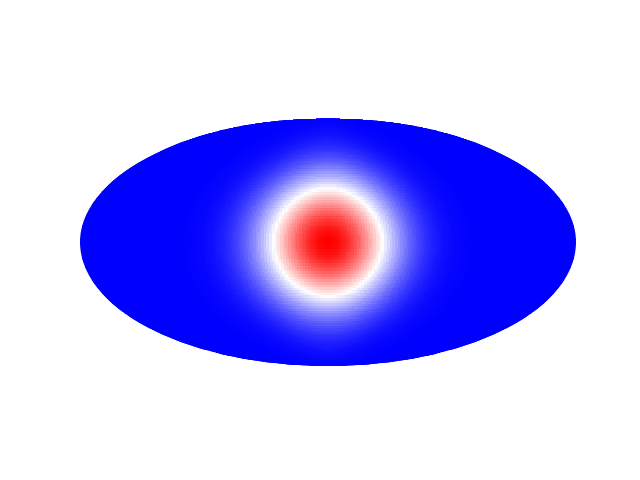

In [6]:
R = displacement(theta, phi, Ix, Iy)
Rdag = R.dag()
psi0 = scs_ket(spin_dim, theta, phi, Ix, Iy, Iz)
tomo_plot_hammer(psi0, 'h')

OTOC growth C = 0.099702


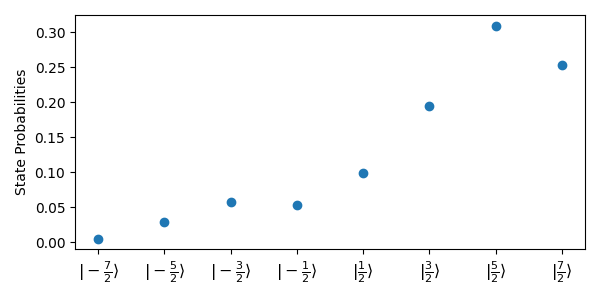

In [ ]:
gamma = 2*np.pi*400
Hzz = Hz_order(gamma, 2)
rabi_strength = 2*np.pi*1/(2*(1888409/1e9))
Hy = rabi_strength * -Iy#-Iy
H_drive = Hy + Hzz

tau = 1.0e-3
Uy  = (-1j * tau * Qobj(Hy)).expm()
Uzz = (-1j * tau * Qobj(Hzz)).expm()


# U   = Uzz * Uy
U   = (-1j * tau * H_drive).expm()

psi0 = psi0 * psi0.dag()
psi = U * psi0 * U.dag()
probs = probs_in_Hprime_basis(psi, theta, phi)
F_k, _ = otoc_from_populations(m_vals, probs, eps)

# OTOC growth (Loschmidt-echo style): C(t) = 1 - F(t)
C_k = 1.0 - float(np.real_if_close(F_k))
print(f"OTOC growth C = {C_k:.6f}")

xticks = [0,1,2,3,4,5,6, 7]
xtick_labels = [
    r"$|-\frac{7}{2} \rangle$",
    r"$|-\frac{5}{2}\rangle$",
    r"$|-\frac{3}{2}\rangle$",
    r"$|-\frac{1}{2}\rangle$",
    r"$|\frac{1}{2}\rangle$",
    r"$|\frac{3}{2}\rangle$",
    r"$|\frac{5}{2}\rangle$",
    r"$|\frac{7}{2}\rangle$",
]


plt.figure(figsize=(6,3))
plt.ylabel('State Probabilities')
plt.xticks(xticks, xtick_labels, fontsize=11.5)
plt.scatter(xticks, probs)
plt.tight_layout()
plt.show()

# OTOC for continous evolution

In [ ]:
# ----- Time domain setup -----
t_max = 3e-3
t_step = 30e-6
time = np.arange(0, t_max, t_step)
N = len(time)

# Initial state and density matrix
theta = np.pi/2
phi = 0
psi0 = scs_ket(spin_dim, theta, phi, Ix, Iy, Iz)
rho0 = psi0 * psi0.dag()

# Preallocate trajectory
rho_t_direct = [None] * N
rho_t_direct[0] = rho0

# --- initialise lists with t=0 ---
eps = 0.2
probs0 = probs_in_Hprime_basis(rho0, theta, phi)
F0, _ = otoc_from_populations(m_vals, probs0, eps)
C0 = 1 - float(np.real_if_close(F0))

probs_list = [probs0]
C_k_list = [C0]

# --- time evolution loop ---
for n in range(1, N):
    H = H_drive
    HH = -1j * t_step * Qobj(H)
    U = HH.expm()
    # U = Uzz * Uy
    rho_t_direct[n] = U * rho_t_direct[n-1] * U.dag()

    probs = probs_in_Hprime_basis(rho_t_direct[n], theta, phi)
    F_k, _ = otoc_from_populations(m_vals, probs, eps)

    probs_list.append(probs)
    C_k_list.append(1 - float(np.real_if_close(F_k)))


/var/folders/g_/byj141xd3bl118bhygqgnv5h0000gn/T/ipykernel_27297/4098904187.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


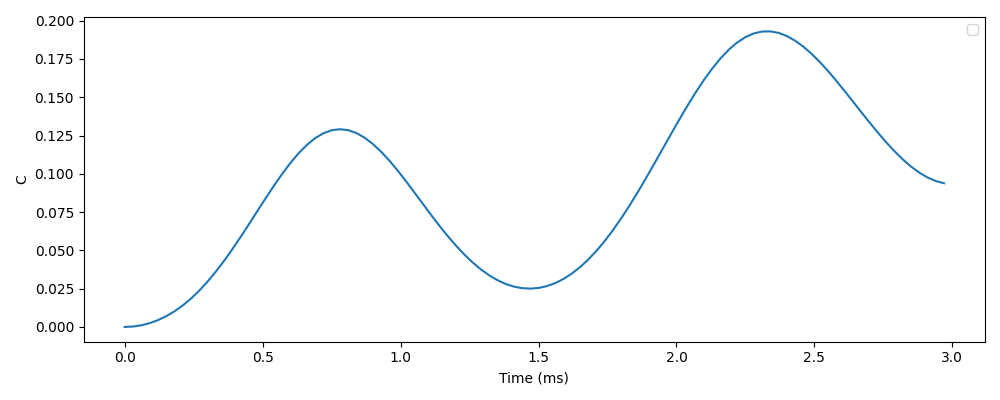

In [ ]:
plt.figure(figsize=(10,4))
plt.plot(time*1e3, C_k_list)

plt.xlabel('Time (ms)')
plt.ylabel('C')
plt.legend()
plt.tight_layout()
plt.show()

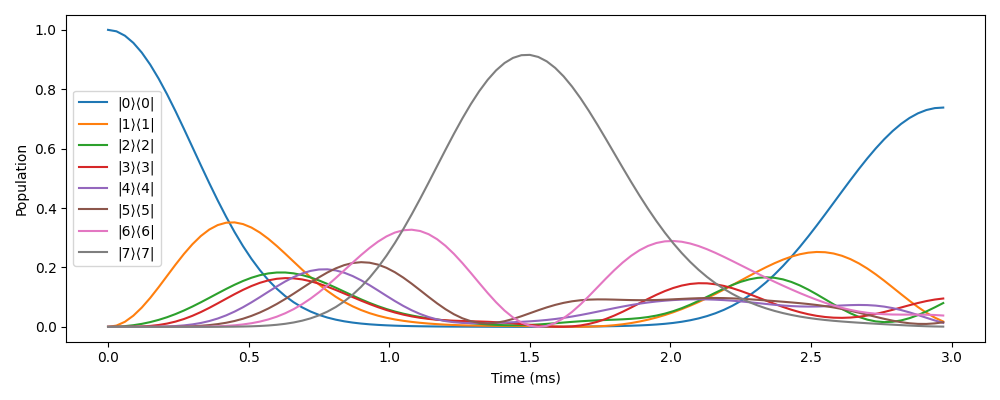

In [ ]:
plt.figure(figsize=(10,4))
# Convert list-of-lists into 2D NumPy array: shape (N, d)
probs_arr = np.array(probs_list)   # N × d

for j in range(d):
    plt.plot(time*1e3, probs_arr[:, j], label=f'|{j}⟩⟨{j}|')

plt.xlabel('Time (ms)')
plt.ylabel('Population')
plt.legend()
plt.tight_layout()
plt.show()

# Sweep trotter number

In [ ]:
# --- Sweep over Trotter numbers ---
trotter_num = 20
trotter_num_list = np.arange(1, trotter_num+1)
t_max = 3e-3  # use your existing scalar (seconds)

C_traces = {}  # N -> list of F_k for k=1..N

for N in trotter_num_list:
    dt = t_max / N
    Uy  = (-1j * dt * Qobj(Hy)).expm()
    Uzz = (-1j * dt * Qobj(Hzz)).expm()
    U   = Uzz * Uy

    psi = psi0 * psi0.dag()
    C_Iist = []
    for k in range(1, N+1):
        psi = U * psi * U.dag()
        probs = probs_in_Hprime_basis(psi, theta, phi)
        F_k, _ = otoc_from_populations(m_vals, probs, eps)
        C_Iist.append(1 - float(np.real(F_k)))
    C_traces[int(N)] = C_Iist

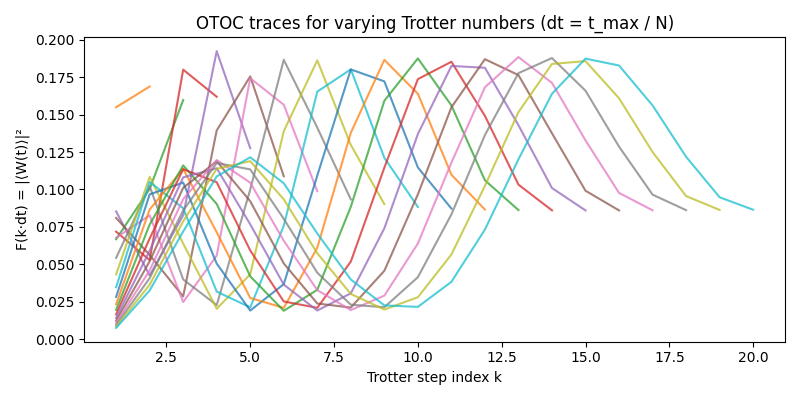

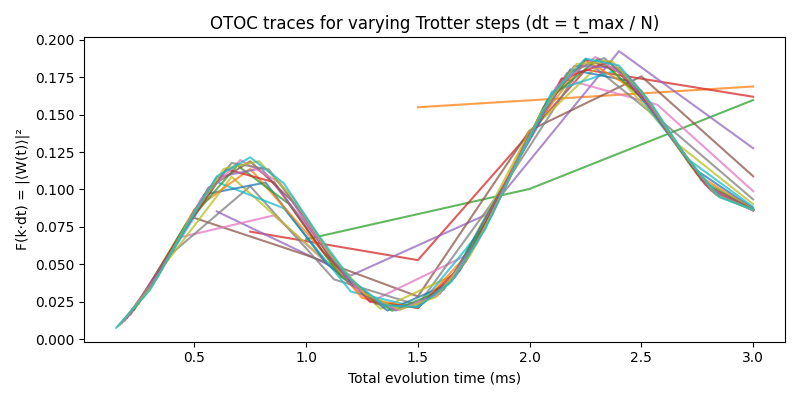

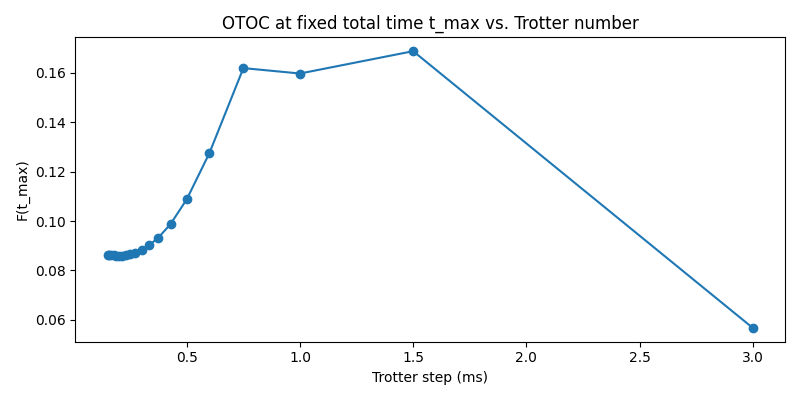

In [ ]:
# --- Plot: OTOC vs Trotter step index for each N ---
plt.figure(figsize=(8,4))
for N, C_Iist in C_traces.items():
    x = np.arange(1, N+1)
    plt.plot(x, C_Iist, alpha=0.75)  # many curves; keep translucent

# Optionally highlight a few representative Ns
# for N_high in [50, 25, 10, 5, 1]:
#     if N_high in C_traces:
#         x = np.arange(1, N_high+1)
#         plt.plot(x, C_traces[N_high], linewidth=2)

plt.xlabel("Trotter step index k")
plt.ylabel("F(k·dt) = |⟨W(t)⟩|²")
plt.title("OTOC traces for varying Trotter numbers (dt = t_max / N)")
plt.tight_layout()
plt.show()

# --- If you also want one value per N at final time t_max (i.e., k=N) ---
N_list_sorted = sorted(C_traces.keys())
F_final = [C_traces[N][-1] for N in N_list_sorted]

plt.figure(figsize=(8,4))
# --- If you also want one value per N at final time t_max (i.e., k=N) ---
for N, C_Iist in C_traces.items():
    dt = t_max / N
    t_axis = np.arange(1, N+1) * dt
    plt.plot(t_axis * 1e3, C_Iist, alpha=0.75)

plt.xlabel("Total evolution time (ms)")
plt.ylabel("F(k·dt) = |⟨W(t)⟩|²")
plt.title("OTOC traces for varying Trotter steps (dt = t_max / N)")
plt.tight_layout()
plt.show()



plt.figure(figsize=(8,4))
# plt.ylim([0,1])
plt.plot(t_max/np.array(N_list_sorted) * 1e3, F_final, marker='o')
plt.xlabel("Trotter step (ms)")
plt.ylabel("F(t_max)")
plt.title("OTOC at fixed total time t_max vs. Trotter number")
plt.tight_layout()
plt.show()